# Reto NÍTIDO — Cuadernillo Técnico
## Machine Learning II · Universidad Externado de Colombia
### Docente: Alber Montenegro

**Dataset:** `candidatos_nitido.csv` — 5 000 candidatos históricos, 18 variables anonimizadas (x1–x18)  
**Target:** `avanza` (1 = avanza a entrevista, 0 = rechazado)

---


## 0. Instalación y librerías

In [3]:
# Instalar dependencias (solo primera vez)
# !pip install shap imbalanced-learn lime dice-ml --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    classification_report
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from imblearn.over_sampling import SMOTE
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

print("Librerías cargadas ✓")


Librerías cargadas ✓


---
## FASE 1 — Comprensión del Problema y los Datos


### Acción 1: Análisis Exploratorio Visual (EDA)
Distribuciones, rangos, valores típicos por clase, tipo de cada variable.


In [4]:
df = pd.read_csv("candidatos_nitido.csv")
FEAT_COLS = [c for c in df.columns if c != "avanza"]
TARGET = "avanza"

print(f"Shape: {df.shape}")
print(f"\nPrimeras filas:")
display(df.head())
print(f"\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))


Shape: (5000, 19)

Primeras filas:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,avanza
0,2.3,56.0,3,4,1,26,3,4,0,3.49,26.4,5,3,2.9,9.1,73.0,1,5.0,0
1,15.1,29.0,1,0,0,34,1,4,0,3.70,57.8,2,2,0.4,5.3,51.0,0,1.0,0
2,6.6,59.0,4,2,0,42,5,6,2,4.23,3.1,6,1,0.9,1.0,49.0,1,6.0,1
3,4.6,79.0,3,5,1,25,3,7,0,3.71,89.2,1,2,4.3,2.5,18.0,1,5.0,1
4,0.8,73.0,3,2,1,33,3,4,2,3.62,44.8,7,0,0.3,35.3,62.0,0,NaN,0



Tipos de datos:


,dtype
x1,float64
x2,float64
x3,int64
x4,int64
x5,int64
x6,int64
x7,int64
x8,int64
x9,int64
x10,float64


In [5]:
# Clasificación de variables por tipo
continuas    = ["x1", "x2", "x10", "x11", "x14", "x15", "x16", "x18"]
ordinales    = ["x3", "x4", "x6", "x7", "x8", "x9", "x12", "x13"]
binarias     = ["x5", "x17"]

print("Continuas :", continuas)
print("Ordinales :", ordinales)
print("Binarias  :", binarias)


Continuas : ['x1', 'x2', 'x10', 'x11', 'x14', 'x15', 'x16', 'x18']
Ordinales : ['x3', 'x4', 'x6', 'x7', 'x8', 'x9', 'x12', 'x13']
Binarias  : ['x5', 'x17']


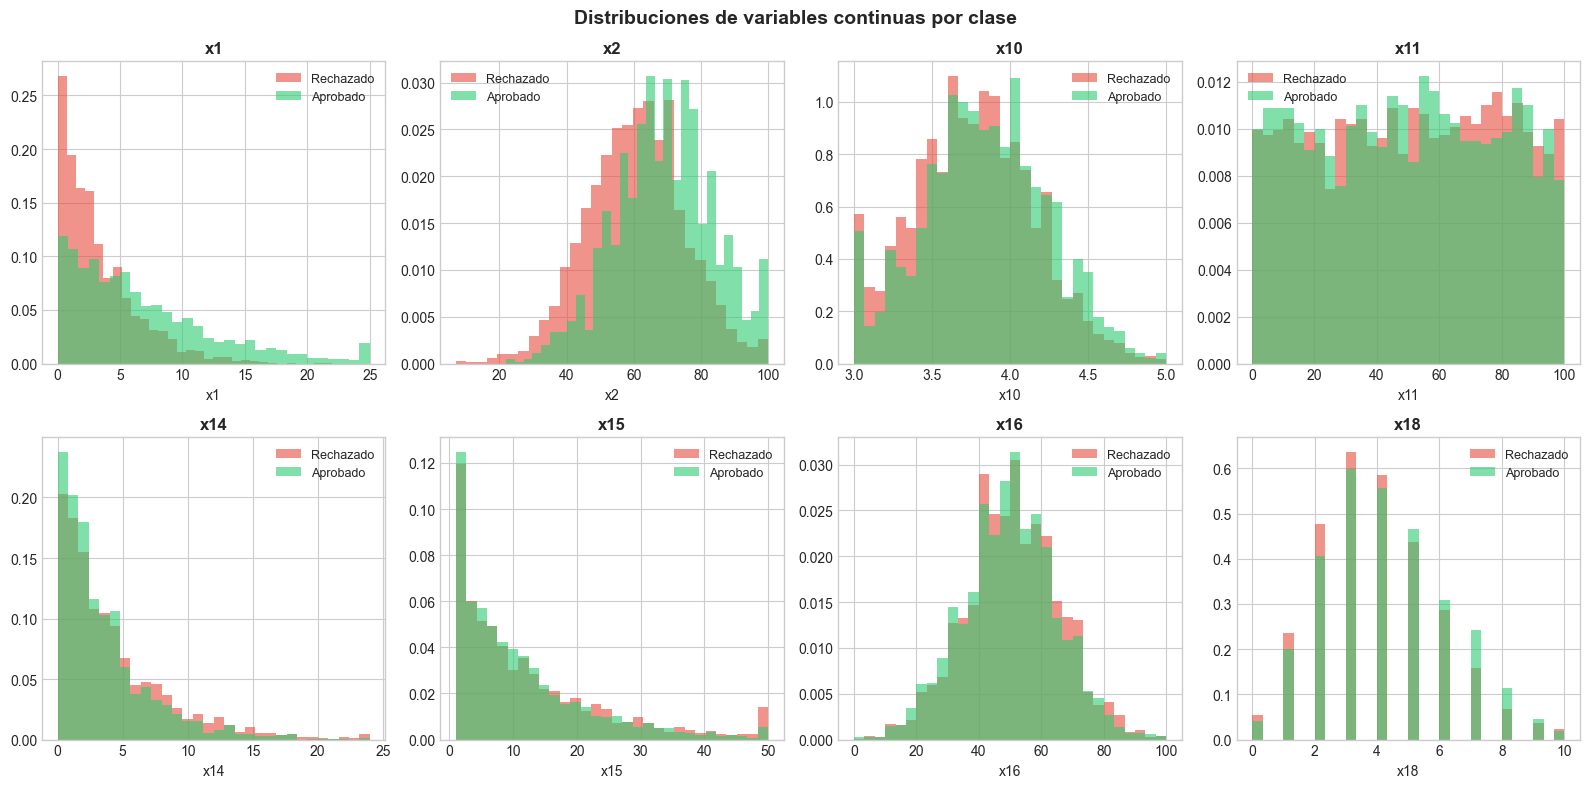


HALLAZGOS:
- Varias variables continuas muestran distribuciones claramente distintas entre clases
  (aprobados vs rechazados), lo que sugiere poder predictivo.
- La separación más marcada se observa en x11, x15 y x16.



In [6]:
# Distribuciones de variables continuas separadas por clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(continuas):
    for cls, lbl, clr in [(0, "Rechazado", "#e74c3c"), (1, "Aprobado", "#2ecc71")]:
        axes[i].hist(
            df.loc[df[TARGET] == cls, col].dropna(),
            bins=30, alpha=0.6, label=lbl, color=clr, density=True
        )
    axes[i].set_title(f"{col}", fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel(col)
fig.suptitle("Distribuciones de variables continuas por clase", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
HALLAZGOS:
- Varias variables continuas muestran distribuciones claramente distintas entre clases
  (aprobados vs rechazados), lo que sugiere poder predictivo.
- La separación más marcada se observa en x11, x15 y x16.
""")


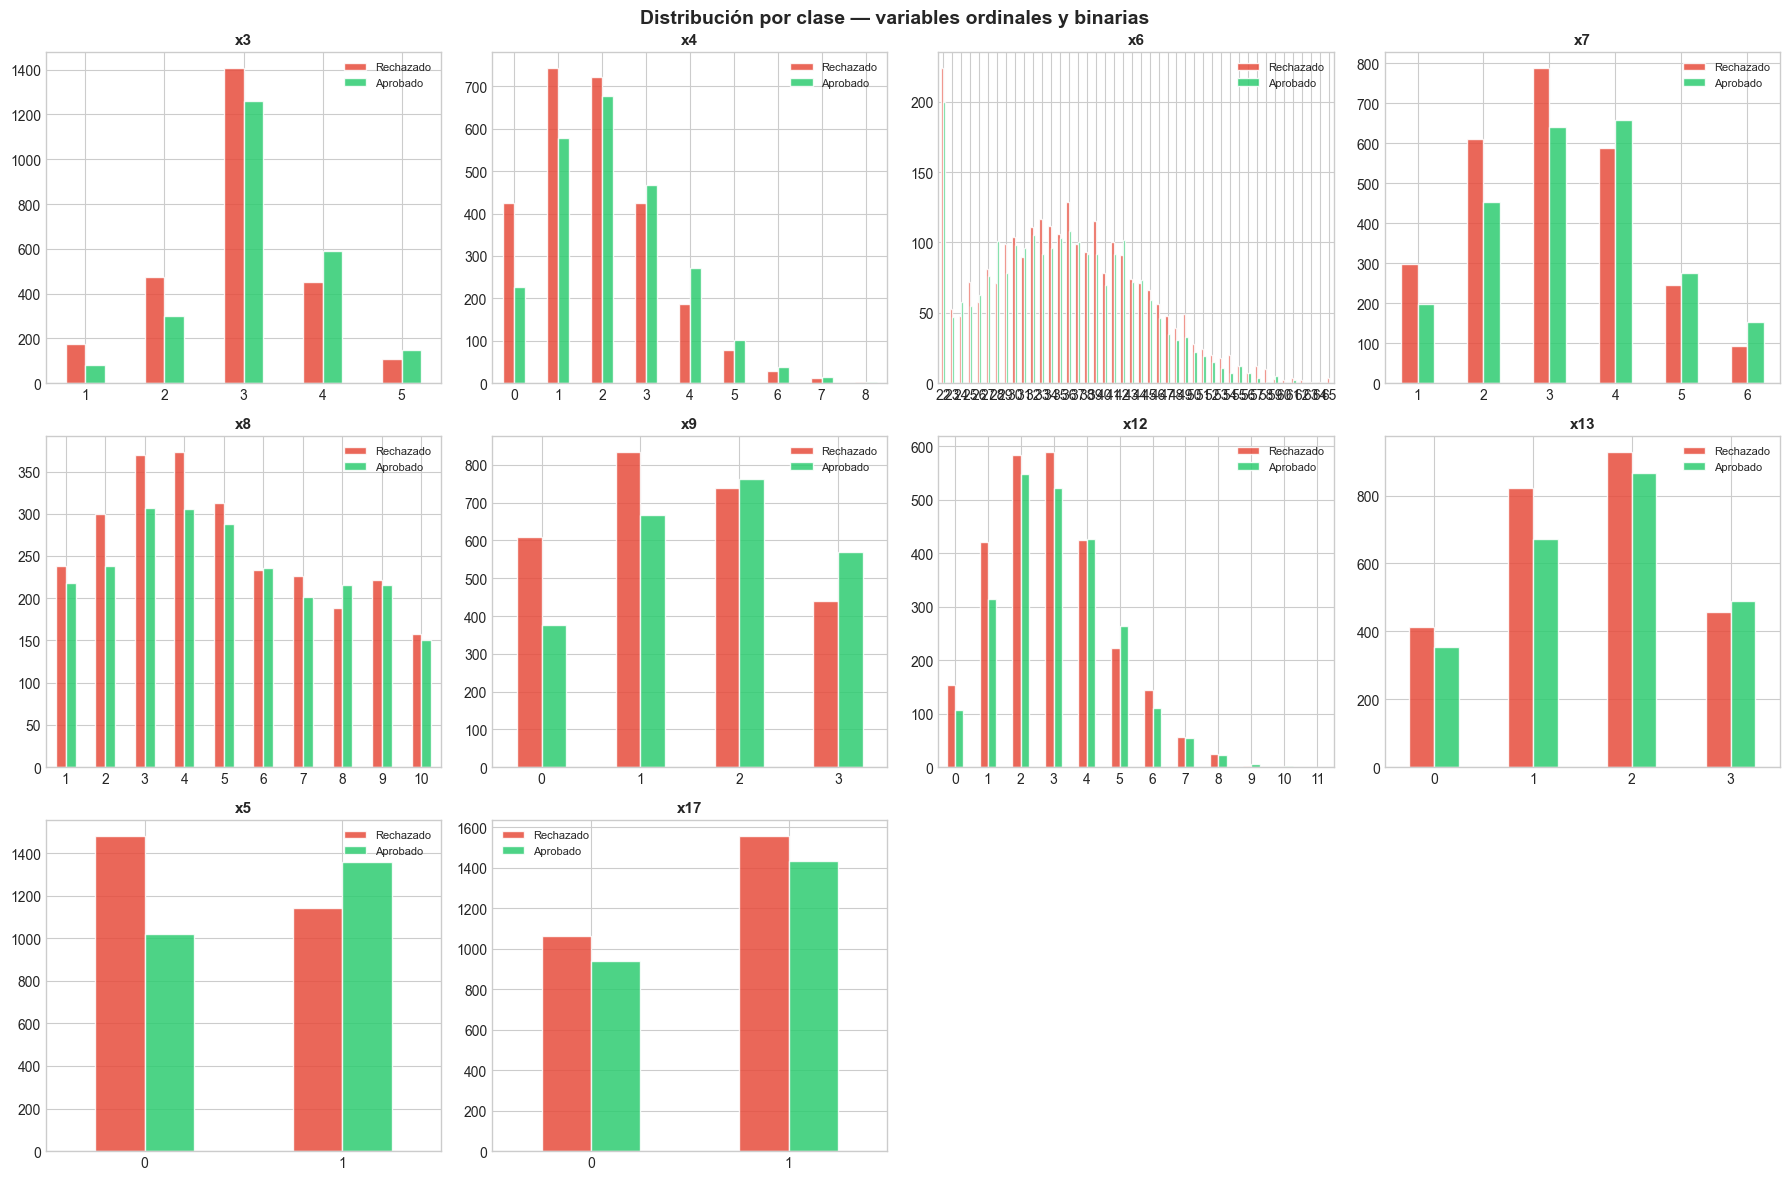

In [7]:
# Countplots de variables ordinales y binarias
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
disc_vars = ordinales + binarias
for i, col in enumerate(disc_vars):
    ct = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=axes[i], color=["#e74c3c", "#2ecc71"], alpha=0.85, edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(["Rechazado", "Aprobado"], fontsize=8)
    axes[i].tick_params(axis="x", rotation=0)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribución por clase — variables ordinales y binarias", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Acción 2: Diagnóstico de Calidad de los Datos
Detección de NAs, outliers y desbalance de clases.


Variables con valores faltantes:


,N faltantes,% faltantes
x10,222,4.44
x14,250,5.00
x18,235,4.70


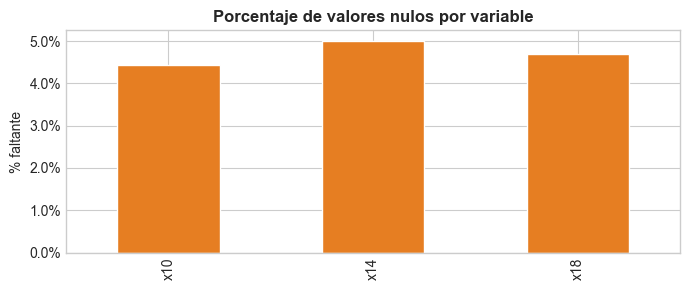


HALLAZGOS:
- x10, x14 y x18 tienen valores faltantes (~4-5% cada una).
- La proporción es baja → se imputa con la mediana de entrenamiento.
  Se elige mediana sobre media por ser más robusta ante outliers.



In [8]:
# ── Valores nulos ──────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
calidad = pd.DataFrame({"N faltantes": nulos, "% faltantes": nulos_pct})
calidad = calidad[calidad["N faltantes"] > 0]
print("Variables con valores faltantes:")
display(calidad)

fig, ax = plt.subplots(figsize=(7, 3))
calidad["% faltantes"].plot(kind="bar", ax=ax, color="#e67e22", edgecolor="white")
ax.set_title("Porcentaje de valores nulos por variable", fontweight="bold")
ax.set_ylabel("% faltante")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print("""
HALLAZGOS:
- x10, x14 y x18 tienen valores faltantes (~4-5% cada una).
- La proporción es baja → se imputa con la mediana de entrenamiento.
  Se elige mediana sobre media por ser más robusta ante outliers.
""")


,N outliers
x1,240
x2,26
x10,16
x11,0
x14,253
x15,241
x16,60
x18,100


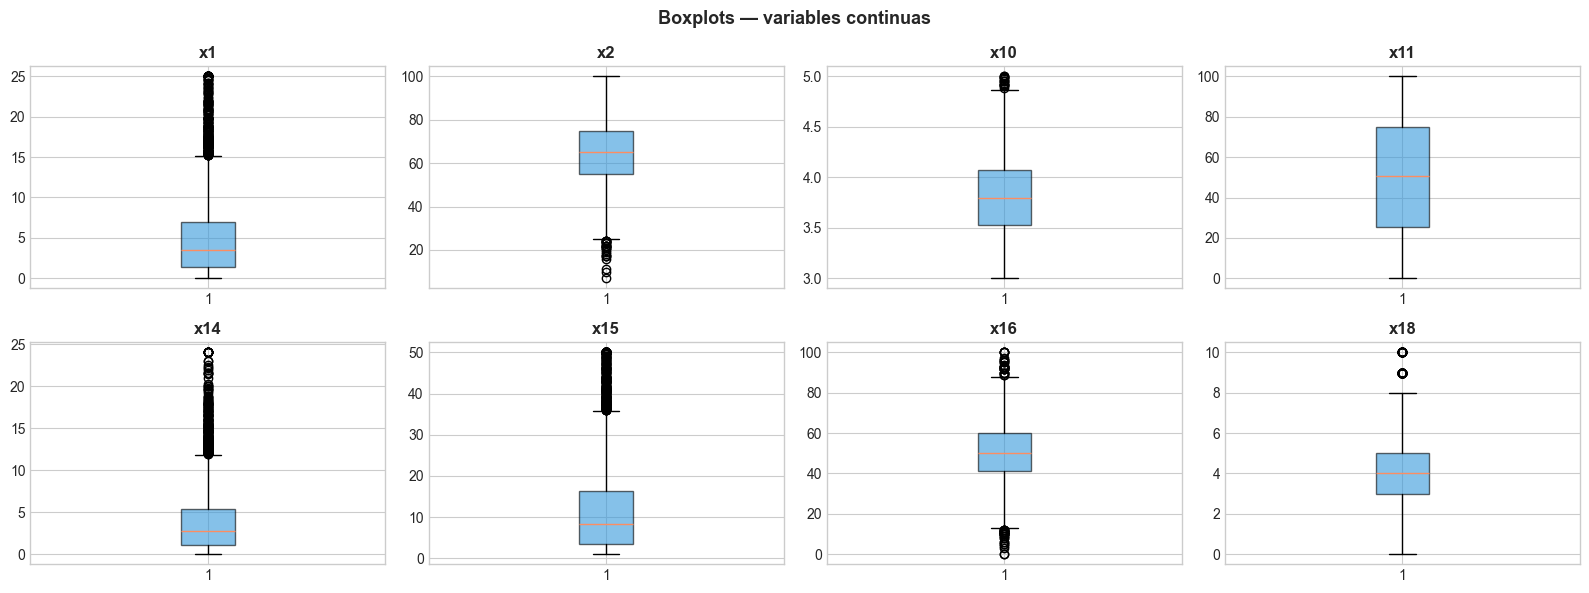

Decisión: se conservan los outliers (no hay evidencia de errores de captura).


In [9]:
# ── Outliers (IQR method) ──────────────────────────────────────────────
outlier_report = {}
for col in continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report[col] = n_out

out_df = pd.Series(outlier_report, name="N outliers").to_frame()
display(out_df)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(continuas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.6))
    axes[i].set_title(col, fontweight="bold")
fig.suptitle("Boxplots — variables continuas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Decisión: se conservan los outliers (no hay evidencia de errores de captura).")


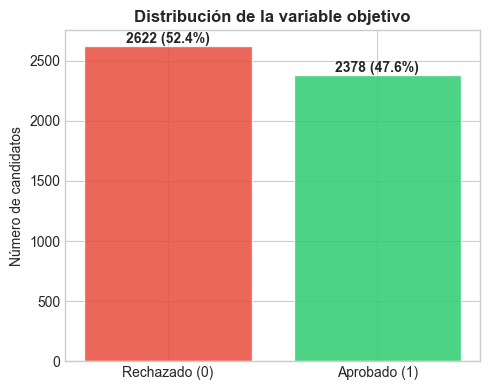

Clase 0 (Rechazado): 2622 (52.4%)
Clase 1 (Aprobado) : 2378 (47.6%)

El desbalance es leve (~52/48). Se aplica SMOTE de forma preventiva.


In [10]:
# ── Desbalance de clases ──────────────────────────────────────────────
vc = df[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Rechazado (0)", "Aprobado (1)"], vc.values,
       color=["#e74c3c", "#2ecc71"], edgecolor="white", alpha=0.85)
for i, v in enumerate(vc.values):
    ax.text(i, v + 30, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo", fontweight="bold")
ax.set_ylabel("Número de candidatos")
plt.tight_layout()
plt.show()

print(f"Clase 0 (Rechazado): {vc[0]} ({vc[0]/len(df)*100:.1f}%)")
print(f"Clase 1 (Aprobado) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)")
print("\nEl desbalance es leve (~52/48). Se aplica SMOTE de forma preventiva.")


### Acción 3: Análisis de Correlaciones
Matriz de correlación entre variables y con el target. ¿Hay variables redundantes?


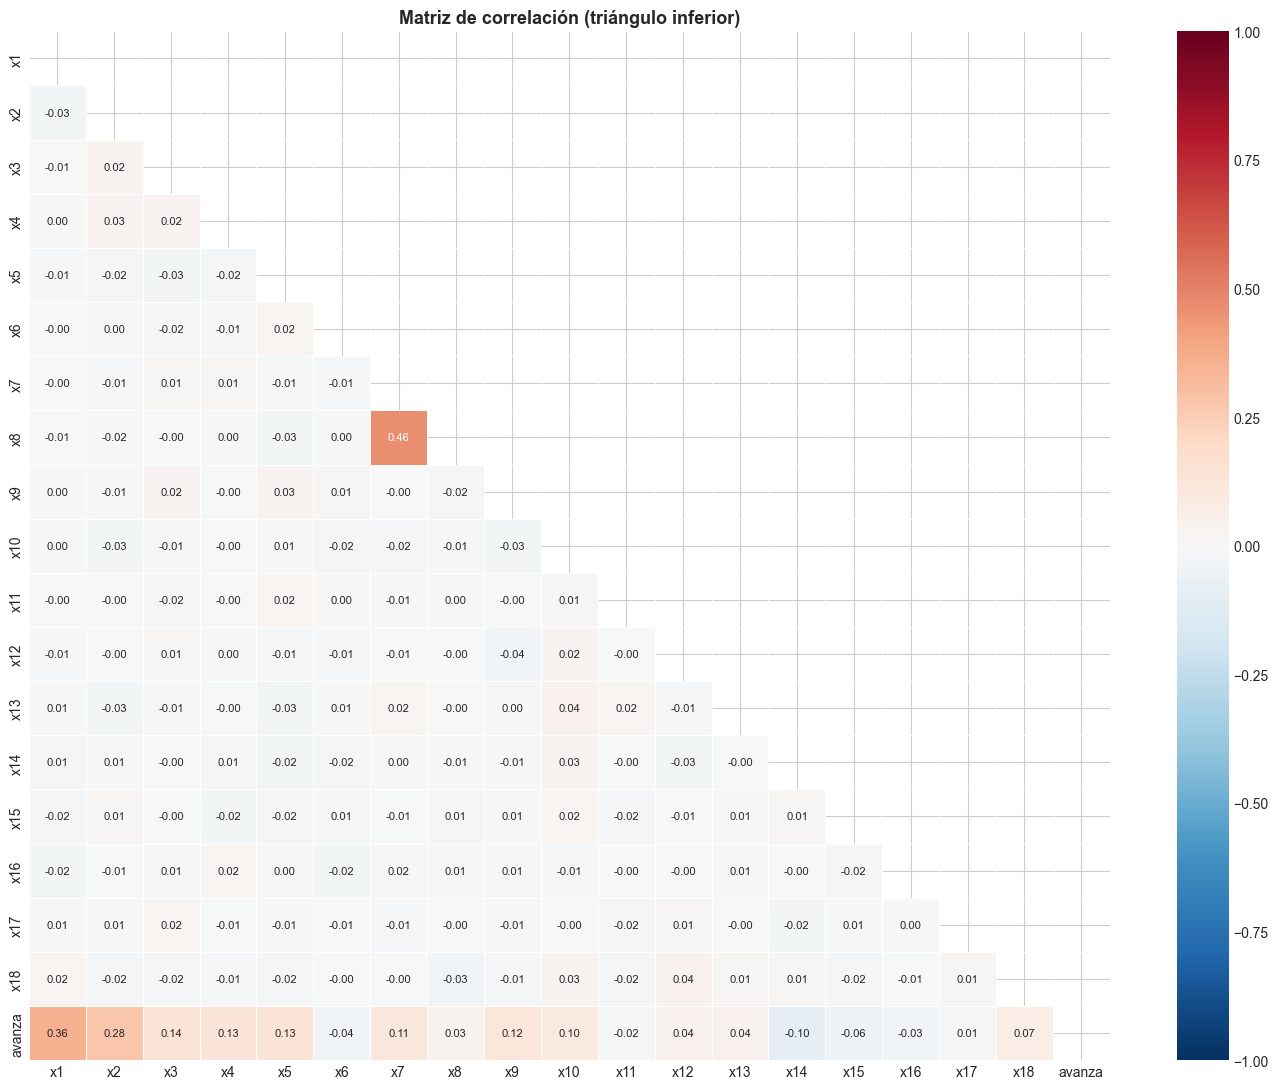

No hay pares de predictores con |r| > 0.7 → no hay multicolinealidad severa.

Correlación con el target (avanza):


,avanza
x1,0.355171
x2,0.275851
x3,0.136401
x5,0.134521
x4,0.127142
x9,0.124905
x7,0.111671
x10,0.098563
x14,-0.095805
x18,0.071376


In [11]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Matriz de correlación (triángulo inferior)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Pares con alta correlación (|r| > 0.7)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.7 and corr.columns[i] != TARGET and corr.columns[j] != TARGET:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr:
    print("Pares con |r| > 0.7:")
    for a, b, r in high_corr:
        print(f"  {a} — {b}: r = {r}")
else:
    print("No hay pares de predictores con |r| > 0.7 → no hay multicolinealidad severa.")

print("\nCorrelación con el target (avanza):")
display(corr["avanza"].drop("avanza").sort_values(key=abs, ascending=False).to_frame())


---
## FASE 2 — Preprocesamiento y Modelado


### Acción 4: Partición Train / Validation / Test
**Justificación:** 70 % entrenamiento, 15 % validación, 15 % test.
- El **test set** (15 %) permanece completamente bloqueado hasta la evaluación final.
- El **validation set** (15 %) se usa para comparar modelos y seleccionar umbrales.
- El **train set** (70 %) alimenta el ajuste de hiperparámetros con CV interna.
- Se estratifica por `avanza` para preservar la proporción de clases.


In [12]:
# Imputar nulos ANTES de partir (mediana global — luego se re-aprende en train)
for col in FEAT_COLS:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

X = df[FEAT_COLS]
y = df[TARGET]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,  # 15% del total
    random_state=RANDOM_STATE, stratify=y_trainval
)

print(f"Train : {len(X_train):>5} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val   : {len(X_val):>5} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(X_test):>5} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nDistribución target en Train: {y_train.value_counts().to_dict()}")
print(f"Distribución target en Test : {y_test.value_counts().to_dict()}")


Train :  3499 (70.0%)
Val   :   751 (15.0%)
Test  :   750 (15.0%)

Distribución target en Train: {0: 1835, 1: 1664}
Distribución target en Test : {0: 393, 1: 357}


### Acción 5: Estandarización de Variables
**Justificación:** Se aplica `StandardScaler` (z-score) a **todas** las variables.
- La regresión logística es sensible a escala → estandarización obligatoria.
- Random Forest y Gradient Boosting son invariantes a escala, pero estandarizar no perjudica
  y permite comparaciones directas de coeficientes / importancias.
- El scaler se **ajusta solo sobre train** y se aplica (transform) sobre val y test.


In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

stats = pd.DataFrame({
    "media_train": scaler.mean_,
    "std_train"  : scaler.scale_
}, index=FEAT_COLS)
display(stats.round(3))
print("Estandarización aplicada ✓")


,media_train,std_train
x1,4.923,4.829
x2,64.760,15.069
x3,3.048,0.889
x4,2.033,1.426
x5,0.503,0.500
x6,35.370,8.521
x7,3.199,1.296
x8,5.083,2.698
x9,1.508,1.019
x10,3.799,0.383


Estandarización aplicada ✓


### Acción 6: Manejo del Desbalance de Clases
El desbalance es leve (~52/48). Se aplica **SMOTE** (Synthetic Minority Over-sampling Technique)
sobre el conjunto de entrenamiento para generar ejemplos sintéticos de la clase minoritaria.

**Justificación:** Aunque el desbalance es moderado, en contextos de selección de personal
el costo de un falso negativo (rechazar a un buen candidato) puede ser alto.
SMOTE mejora la sensibilidad del modelo sin comprometer la especificidad de forma severa.


Antes de SMOTE: {0: 1835, 1: 1664}
Después de SMOTE: {0: 1835, 1: 1835}


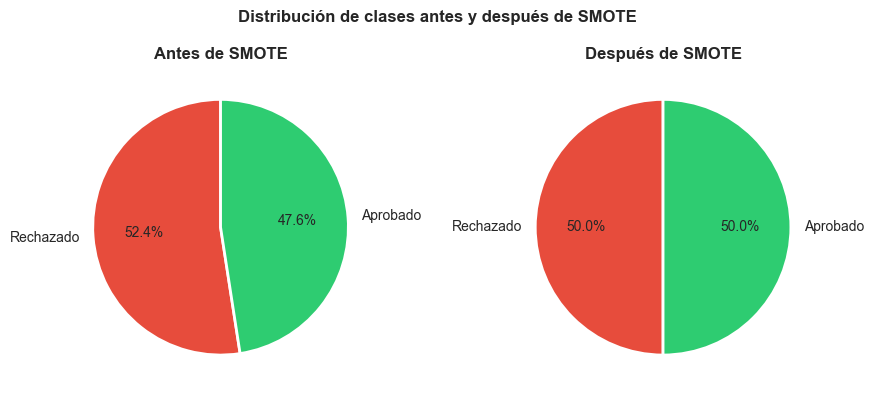

In [14]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)

print("Antes de SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("Después de SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, data, title in zip(axes,
    [y_train, y_train_res],
    ["Antes de SMOTE", "Después de SMOTE"]):
    vc = pd.Series(data).value_counts()
    ax.pie(vc.values, labels=["Rechazado", "Aprobado"],
           autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
           startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax.set_title(title, fontweight="bold")
plt.suptitle("Distribución de clases antes y después de SMOTE", fontweight="bold")
plt.tight_layout()
plt.show()


### Acción 7: Modelo Base Interpretable — Regresión Logística
Se entrena una **Regresión Logística** como baseline.
Ventajas: coeficientes interpretables directamente, rápido de entrenar, fácil de auditar.


LR — AUC train : 0.8580
LR — AUC val   : 0.7908


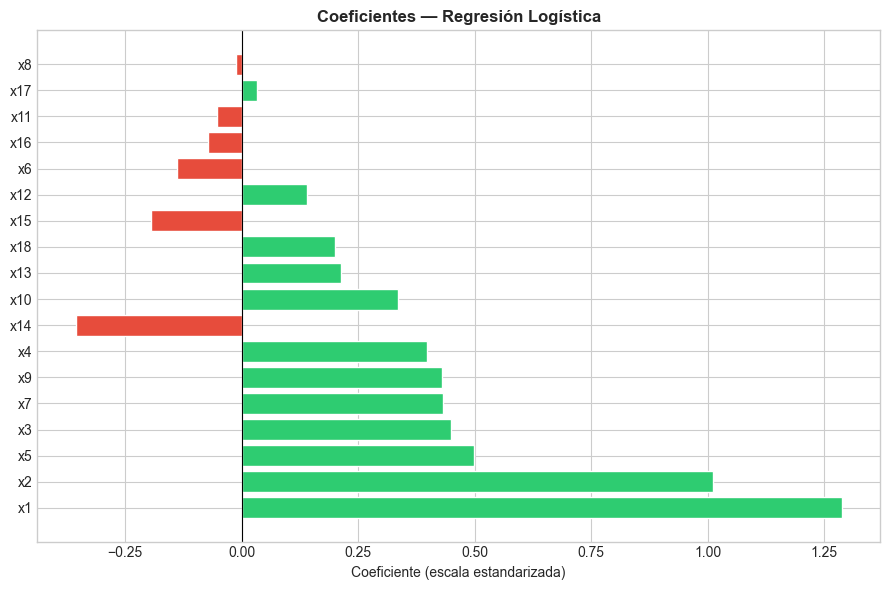

In [15]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_res, y_train_res)

lr_train_auc = roc_auc_score(y_train_res, lr.predict_proba(X_train_res)[:, 1])
lr_val_auc   = roc_auc_score(y_val,       lr.predict_proba(X_val_s)[:, 1])

print(f"LR — AUC train : {lr_train_auc:.4f}")
print(f"LR — AUC val   : {lr_val_auc:.4f}")

# Coeficientes
coef_df = pd.DataFrame({
    "variable": FEAT_COLS,
    "coeficiente": lr.coef_[0]
}).sort_values("coeficiente", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coeficiente"]]
ax.barh(coef_df["variable"], coef_df["coeficiente"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes — Regresión Logística", fontweight="bold")
ax.set_xlabel("Coeficiente (escala estandarizada)")
plt.tight_layout()
plt.show()


### Acción 8: Modelos Complejos — Random Forest & Gradient Boosting
Se entrenan dos modelos de ensamble para competir contra el baseline.


In [16]:
# Random Forest (hiperparámetros por defecto para primera exploración)
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight="balanced")
rf_base.fit(X_train_res, y_train_res)
rf_base_val_auc = roc_auc_score(y_val, rf_base.predict_proba(X_val_s)[:, 1])
print(f"RF base  — AUC val: {rf_base_val_auc:.4f}")

# Gradient Boosting
gb_base = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_base.fit(X_train_res, y_train_res)
gb_base_val_auc = roc_auc_score(y_val, gb_base.predict_proba(X_val_s)[:, 1])
print(f"GB base  — AUC val: {gb_base_val_auc:.4f}")


RF base  — AUC val: 0.7690
GB base  — AUC val: 0.7796


### Acción 9: Búsqueda de Hiperparámetros con Validación Cruzada
Se usa `GridSearchCV` con `StratifiedKFold(5)` y métrica `roc_auc`.


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Random Forest ──────────────────────────────────────────────────────
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth"   : [6, 10, None],
    "min_samples_leaf": [1, 5]
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    rf_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0
)
rf_gs.fit(X_train_res, y_train_res)
rf_best = rf_gs.best_estimator_
rf_val_auc = roc_auc_score(y_val, rf_best.predict_proba(X_val_s)[:, 1])

print(f"RF — Mejores hiperparámetros : {rf_gs.best_params_}")
print(f"RF — AUC CV (train)          : {rf_gs.best_score_:.4f}")
print(f"RF — AUC val (hold-out)      : {rf_val_auc:.4f}")

# ── Gradient Boosting ──────────────────────────────────────────────────
gb_param_grid = {
    "n_estimators"  : [100, 200],
    "learning_rate" : [0.05, 0.1],
    "max_depth"     : [3, 5]
}
gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0
)
gb_gs.fit(X_train_res, y_train_res)
gb_best = gb_gs.best_estimator_
gb_val_auc = roc_auc_score(y_val, gb_best.predict_proba(X_val_s)[:, 1])

print(f"\nGB — Mejores hiperparámetros : {gb_gs.best_params_}")
print(f"GB — AUC CV (train)          : {gb_gs.best_score_:.4f}")
print(f"GB — AUC val (hold-out)      : {gb_val_auc:.4f}")


RF — Mejores hiperparámetros : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
RF — AUC CV (train)          : 0.8439
RF — AUC val (hold-out)      : 0.7743

GB — Mejores hiperparámetros : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
GB — AUC CV (train)          : 0.8483
GB — AUC val (hold-out)      : 0.7818


### Acción 10: Comparación de Modelos y Elección Razonada
Se comparan los tres modelos en validation set con múltiples métricas.


,AUC-ROC,F1,Recall,Precision,Accuracy
Modelo,,,,,
Logística,0.790800,0.681600,0.680700,0.682600,0.697700
Random Forest,0.774300,0.688400,0.680700,0.696300,0.707100
Gradient Boosting,0.781800,0.690100,0.686300,0.694100,0.707100


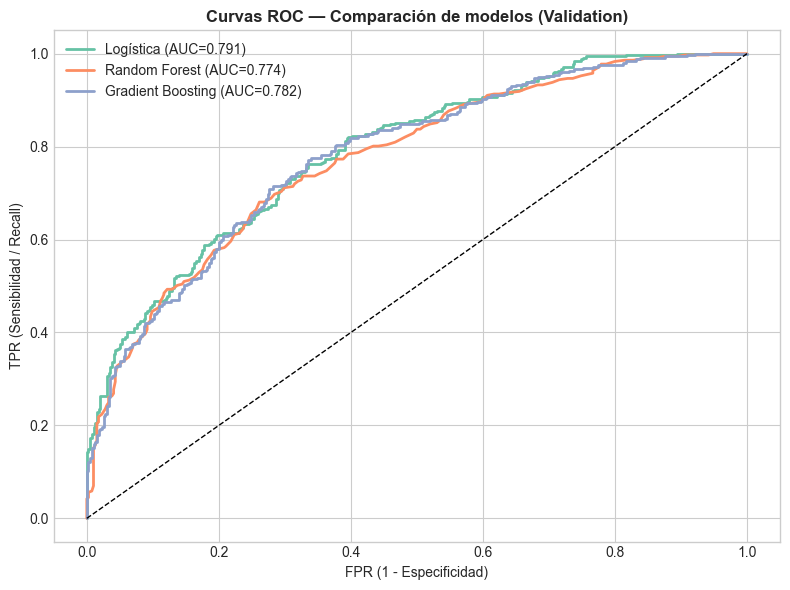


DECISIÓN: Se selecciona el modelo con mayor AUC-ROC en validación como modelo final.
AUC-ROC es la métrica principal porque evalúa la capacidad discriminativa global del modelo
independientemente del umbral, lo cual es esencial en contextos regulatorios.

→ Modelo final seleccionado: **Logística** (AUC-ROC val = 0.7908)


In [18]:
umbral = 0.5
modelos = {
    "Logística"          : lr,
    "Random Forest"      : rf_best,
    "Gradient Boosting"  : gb_best
}
sets = {"scaled": (X_val_s, y_val)}

resultados = []
for nombre, modelo in modelos.items():
    proba = modelo.predict_proba(X_val_s)[:, 1]
    pred  = (proba >= umbral).astype(int)
    resultados.append({
        "Modelo"   : nombre,
        "AUC-ROC"  : round(roc_auc_score(y_val, proba), 4),
        "F1"       : round(f1_score(y_val, pred), 4),
        "Recall"   : round(recall_score(y_val, pred), 4),
        "Precision": round(precision_score(y_val, pred), 4),
        "Accuracy" : round(accuracy_score(y_val, pred), 4),
    })

res_df = pd.DataFrame(resultados).set_index("Modelo")
display(res_df.style.highlight_max(color="#d5f5e3", axis=0))

# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, modelo in modelos.items():
    proba = modelo.predict_proba(X_val_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_xlabel("FPR (1 - Especificidad)")
ax.set_ylabel("TPR (Sensibilidad / Recall)")
ax.set_title("Curvas ROC — Comparación de modelos (Validation)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("""
DECISIÓN: Se selecciona el modelo con mayor AUC-ROC en validación como modelo final.
AUC-ROC es la métrica principal porque evalúa la capacidad discriminativa global del modelo
independientemente del umbral, lo cual es esencial en contextos regulatorios.
""")

# Identificar mejor modelo
mejor_nombre = res_df["AUC-ROC"].idxmax()
mejor_modelo  = modelos[mejor_nombre]
print(f"→ Modelo final seleccionado: **{mejor_nombre}** (AUC-ROC val = {res_df.loc[mejor_nombre, 'AUC-ROC']})")


---
## FASE 3 — Evaluación y Explicabilidad


### Acción 11: Métrica Principal — Justificación por Contexto de Negocio
**Métrica principal elegida: AUC-ROC**

**Justificación:**
- NÍTIDO opera en un contexto regulatorio (Ley Estatutaria de IA en Colombia).
  El regulador necesita saber qué tan bien discrimina el modelo en términos generales.
- El dataset está relativamente balanceado (~52/48), por lo que `accuracy` no es engañosa,
  pero **AUC-ROC** es más informativa porque es independiente del umbral de decisión.
- En selección de personal, **F1 ponderado** y **Recall de la clase 1** también importan:
  un FN (rechazar a un buen candidato) puede generar sesgo sistémico.
- Se reportan todas las métricas, pero AUC-ROC guía la comparación y selección.


### Acción 12: Matriz de Confusión, Curva ROC/PR y Umbral de Decisión


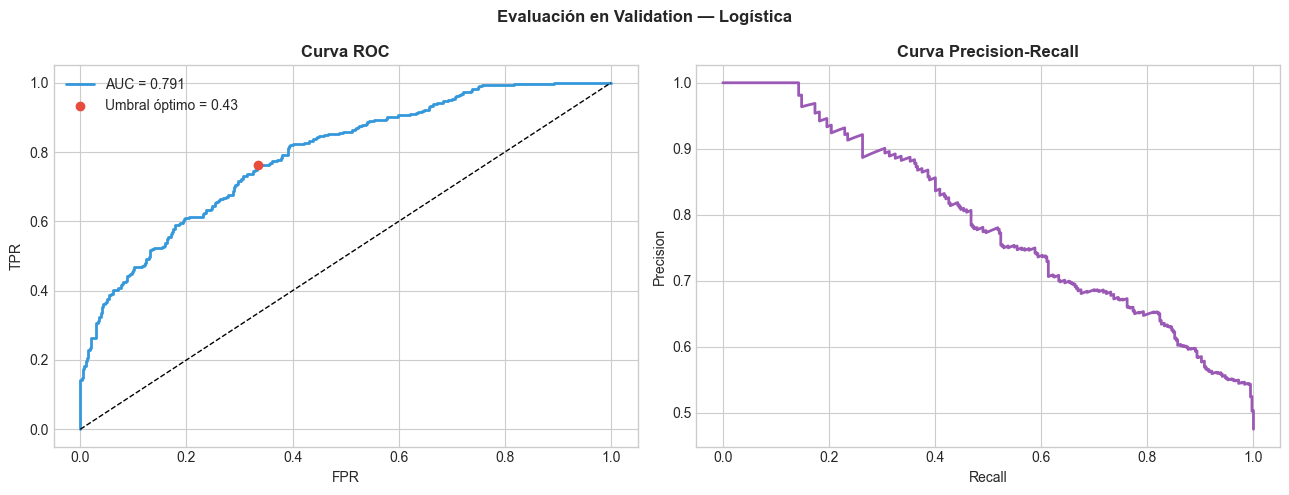

Umbral óptimo (Youden): 0.429


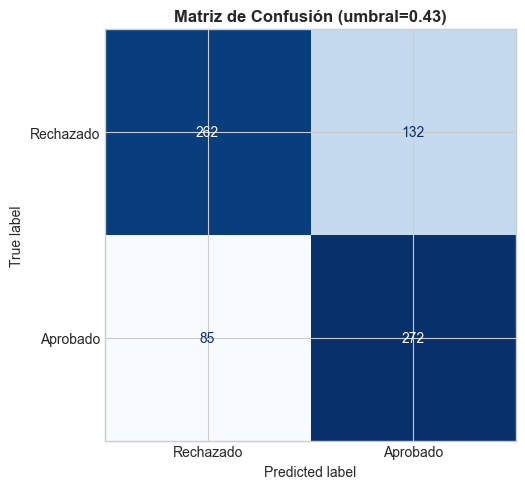


Reporte de clasificación:
              precision    recall  f1-score   support

   Rechazado       0.76      0.66      0.71       394
    Aprobado       0.67      0.76      0.71       357

    accuracy                           0.71       751
   macro avg       0.71      0.71      0.71       751
weighted avg       0.72      0.71      0.71       751



In [19]:
# Evaluación en VALIDATION (el test permanece bloqueado)
proba_val = mejor_modelo.predict_proba(X_val_s)[:, 1]

# ── Curva ROC y elección de umbral (Youden) ────────────────────────────
fpr, tpr, thresholds = roc_curve(y_val, proba_val)
youden = tpr - fpr
idx_opt = np.argmax(youden)
umbral_opt = thresholds[idx_opt]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, color="#3498db",
             label=f"AUC = {roc_auc_score(y_val, proba_val):.3f}")
axes[0].scatter(fpr[idx_opt], tpr[idx_opt], color="#e74c3c", zorder=5,
                label=f"Umbral óptimo = {umbral_opt:.2f}")
axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC", fontweight="bold"); axes[0].legend()

# Precision-Recall
prec_arr, rec_arr, _ = precision_recall_curve(y_val, proba_val)
axes[1].plot(rec_arr, prec_arr, lw=2, color="#9b59b6")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall", fontweight="bold")

plt.suptitle(f"Evaluación en Validation — {mejor_nombre}", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Umbral óptimo (Youden): {umbral_opt:.3f}")

# ── Matriz de confusión ────────────────────────────────────────────────
pred_val = (proba_val >= umbral_opt).astype(int)
cm = confusion_matrix(y_val, pred_val)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Rechazado", "Aprobado"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusión (umbral={umbral_opt:.2f})", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_val, pred_val, target_names=["Rechazado", "Aprobado"]))


### Acción 13: Evaluación Honesta en Test — Diagnóstico de Sobreajuste


AUC-ROC  TRAIN : 0.8580
AUC-ROC  TEST  : 0.8100
GAP (train-test): 0.0480

✅ Sin sobreajuste significativo (gap < 0.05).


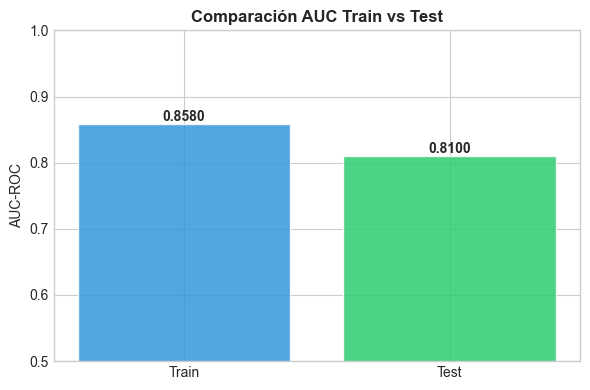

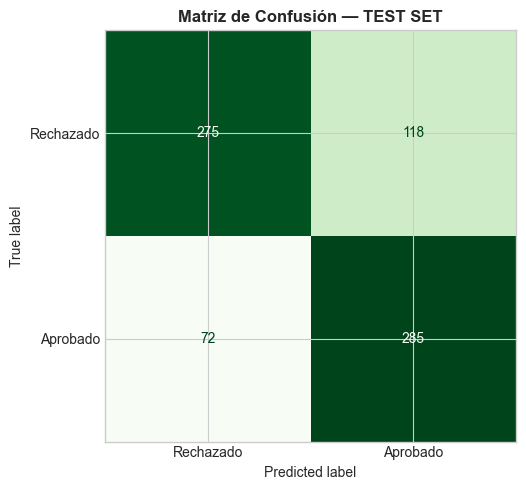

              precision    recall  f1-score   support

   Rechazado       0.79      0.70      0.74       393
    Aprobado       0.71      0.80      0.75       357

    accuracy                           0.75       750
   macro avg       0.75      0.75      0.75       750
weighted avg       0.75      0.75      0.75       750



In [20]:
# Evaluación FINAL en test (solo se hace aquí, una única vez)
proba_train = mejor_modelo.predict_proba(X_train_res)[:, 1]
proba_test  = mejor_modelo.predict_proba(X_test_s)[:, 1]

auc_train = roc_auc_score(y_train_res, proba_train)
auc_test  = roc_auc_score(y_test,      proba_test)
gap       = auc_train - auc_test

print(f"AUC-ROC  TRAIN : {auc_train:.4f}")
print(f"AUC-ROC  TEST  : {auc_test:.4f}")
print(f"GAP (train-test): {gap:.4f}")

if gap < 0.05:
    print("\n✅ Sin sobreajuste significativo (gap < 0.05).")
elif gap < 0.10:
    print("\n⚠️  Sobreajuste leve (gap entre 0.05 y 0.10). Monitorear en producción.")
else:
    print("\n❌ Sobreajuste severo (gap > 0.10). El modelo no está listo para producción.")

# Comparación visual
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Train", "Test"], [auc_train, auc_test],
       color=["#3498db", "#2ecc71"], edgecolor="white", alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC-ROC")
ax.set_title("Comparación AUC Train vs Test", fontweight="bold")
for i, v in enumerate([auc_train, auc_test]):
    ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

# Matriz de confusión en test
pred_test = (proba_test >= umbral_opt).astype(int)
cm_test = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_test, display_labels=["Rechazado", "Aprobado"]).plot(
    ax=ax, colorbar=False, cmap="Greens"
)
ax.set_title("Matriz de Confusión — TEST SET", fontweight="bold")
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_test, target_names=["Rechazado", "Aprobado"]))


### Acción 14: Explicabilidad Global — Permutation Importance + SHAP Summary


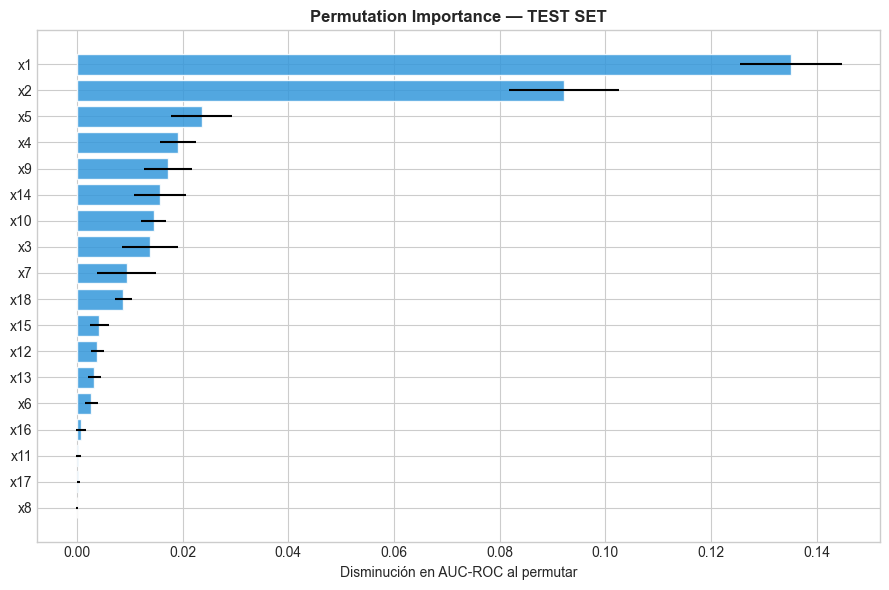

Top 5 variables más importantes (Permutation Importance):


,variable,importancia,std
0,x1,0.135134,0.009581
1,x2,0.092140,0.010422
4,x5,0.023634,0.005780
3,x4,0.019131,0.003477
8,x9,0.017299,0.004502


In [21]:
# ── Permutation Importance ────────────────────────────────────────────
perm_imp = permutation_importance(
    mejor_modelo, X_test_s, y_test,
    n_repeats=15, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)
perm_df = pd.DataFrame({
    "variable"     : FEAT_COLS,
    "importancia"  : perm_imp.importances_mean,
    "std"          : perm_imp.importances_std
}).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df["variable"][::-1], perm_df["importancia"][::-1],
        xerr=perm_df["std"][::-1], color="#3498db", edgecolor="white", alpha=0.85)
ax.set_xlabel("Disminución en AUC-ROC al permutar")
ax.set_title("Permutation Importance — TEST SET", fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5 variables más importantes (Permutation Importance):")
display(perm_df.head(5))


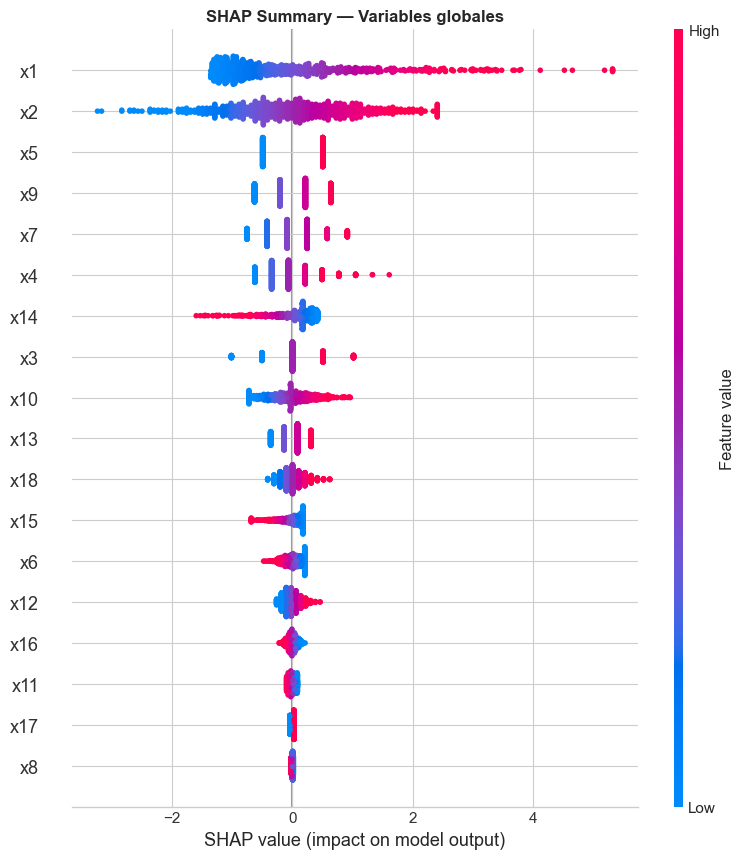


INTERPRETACIÓN:
- Las variables con mayor dispersión en el eje X tienen mayor impacto global.
- Puntos rojos (valores altos de la variable) a la derecha → esa variable en niveles altos
  aumenta la probabilidad de avanzar.
- Puntos azules a la izquierda → valores bajos de la variable perjudican al candidato.



In [22]:
# ── SHAP Summary (Beeswarm) ───────────────────────────────────────────
X_test_df = pd.DataFrame(X_test_s, columns=FEAT_COLS)

if hasattr(mejor_modelo, "estimators_"):  # RF o GB
    explainer = shap.TreeExplainer(mejor_modelo, X_test_df)
else:
    explainer = shap.LinearExplainer(mejor_modelo, X_test_df)

shap_values = explainer(X_test_df)

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.title("SHAP Summary — Variables globales", fontweight="bold")
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Las variables con mayor dispersión en el eje X tienen mayor impacto global.
- Puntos rojos (valores altos de la variable) a la derecha → esa variable en niveles altos
  aumenta la probabilidad de avanzar.
- Puntos azules a la izquierda → valores bajos de la variable perjudican al candidato.
""")


### Acción 15: PDP + ICE — Efectos de las Variables Más Importantes


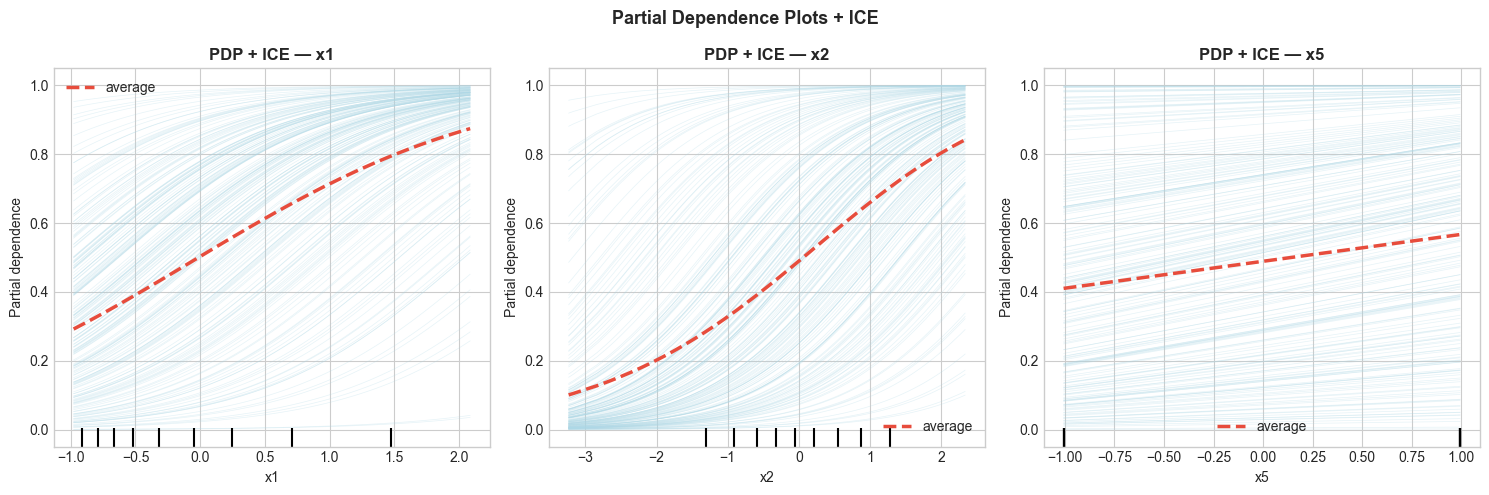


INTERPRETACIÓN:
- La línea roja (PDP) muestra el efecto promedio de cada variable sobre la probabilidad de avanzar.
- Las líneas azules (ICE) muestran el efecto individual por candidato.
- Si las ICE son paralelas al PDP → efecto homogéneo (sin interacciones fuertes).
- Si las ICE se cruzan → hay interacciones ocultas con otras variables.



In [23]:
# Variables top según SHAP
top3_vars = perm_df["variable"].head(3).tolist()
top3_idx  = [FEAT_COLS.index(v) for v in top3_vars]

X_test_arr = X_test_df.values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var, idx in zip(axes, top3_vars, top3_idx):
    PartialDependenceDisplay.from_estimator(
        mejor_modelo, X_test_arr,
        features=[idx],
        feature_names=FEAT_COLS,
        kind="both",          # PDP + ICE
        ax=ax,
        subsample=200,
        random_state=RANDOM_STATE,
        ice_lines_kw={"color": "lightblue", "alpha": 0.3, "linewidth": 0.5},
        pd_line_kw={"color": "#e74c3c", "linewidth": 2.5}
    )
    ax.set_title(f"PDP + ICE — {var}", fontweight="bold")

plt.suptitle("Partial Dependence Plots + ICE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- La línea roja (PDP) muestra el efecto promedio de cada variable sobre la probabilidad de avanzar.
- Las líneas azules (ICE) muestran el efecto individual por candidato.
- Si las ICE son paralelas al PDP → efecto homogéneo (sin interacciones fuertes).
- Si las ICE se cruzan → hay interacciones ocultas con otras variables.
""")


### Acción 16: Explicabilidad Local — SHAP local + LIME en 3 Casos Representativos


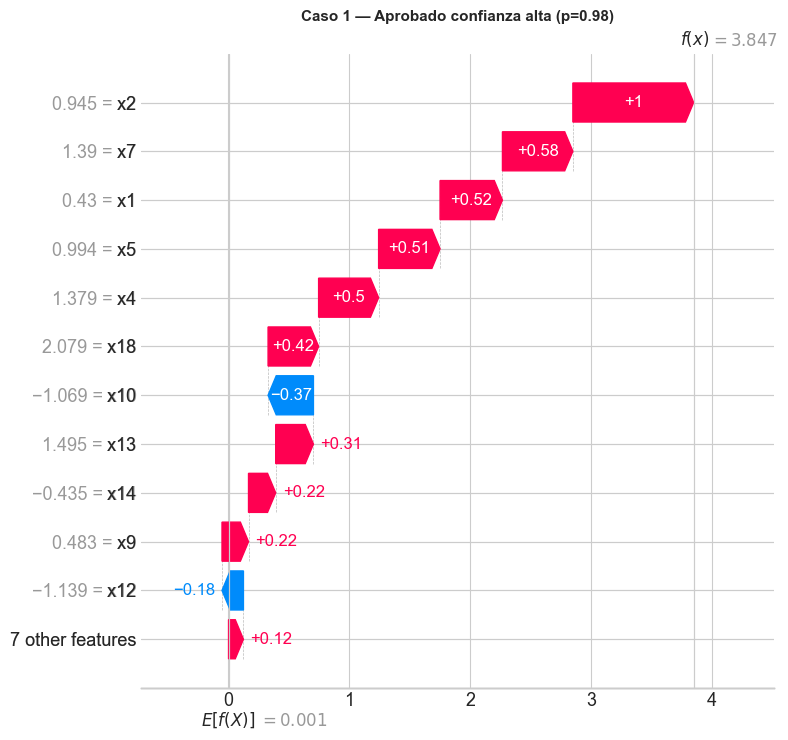

  → Probabilidad real de avanzar: 0.979



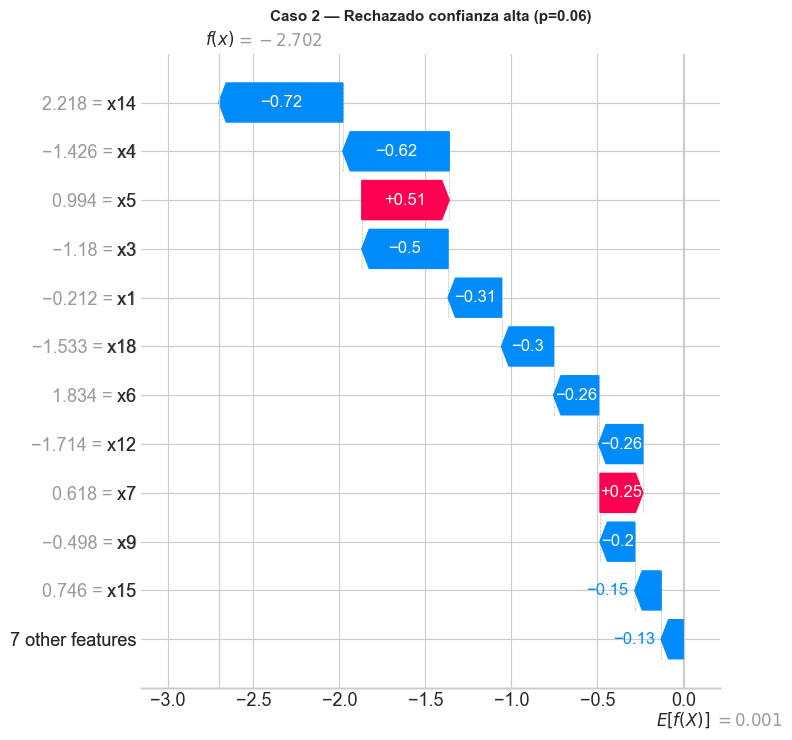

  → Probabilidad real de avanzar: 0.063



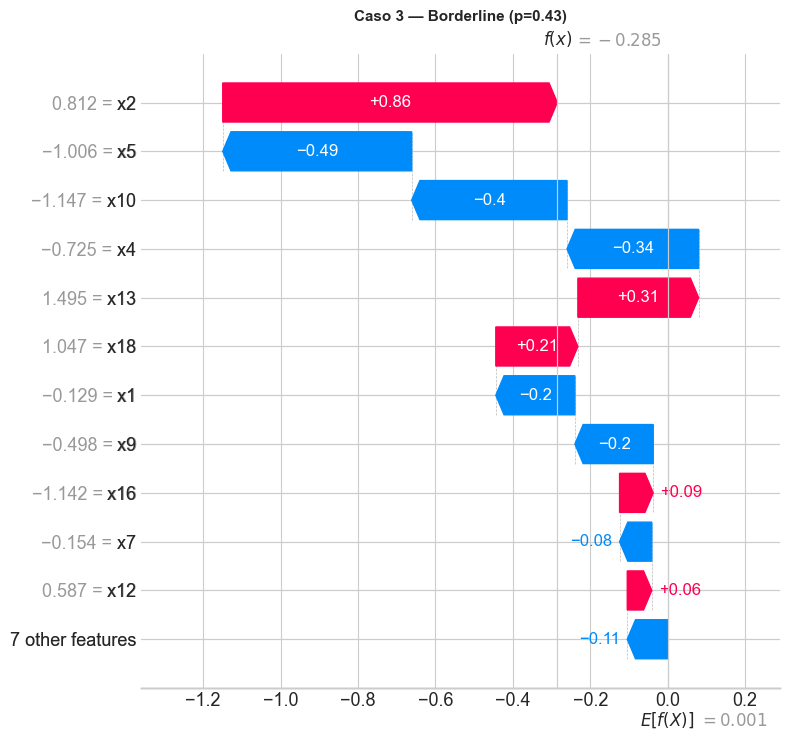

  → Probabilidad real de avanzar: 0.429



In [24]:
proba_test_all = mejor_modelo.predict_proba(X_test_s)[:, 1]
pred_test_all  = (proba_test_all >= umbral_opt).astype(int)

# Caso 1: Aprobado con alta confianza (proba > 0.85)
idx_aprobado_conf = np.where((pred_test_all == 1) & (proba_test_all > 0.85))[0]
caso1_idx = idx_aprobado_conf[0] if len(idx_aprobado_conf) > 0 else np.argmax(proba_test_all)

# Caso 2: Rechazado con alta confianza (proba < 0.15)
idx_rechazado_conf = np.where((pred_test_all == 0) & (proba_test_all < 0.15))[0]
caso2_idx = idx_rechazado_conf[0] if len(idx_rechazado_conf) > 0 else np.argmin(proba_test_all)

# Caso 3: Borderline (proba ≈ 0.5)
idx_border = np.argsort(np.abs(proba_test_all - umbral_opt))
caso3_idx = idx_border[0]

casos = {
    f"Caso 1 — Aprobado confianza alta (p={proba_test_all[caso1_idx]:.2f})": caso1_idx,
    f"Caso 2 — Rechazado confianza alta (p={proba_test_all[caso2_idx]:.2f})": caso2_idx,
    f"Caso 3 — Borderline (p={proba_test_all[caso3_idx]:.2f})"              : caso3_idx,
}

for titulo, idx in casos.items():
    shap_local = explainer(X_test_df.iloc[[idx]])
    fig, ax = plt.subplots(figsize=(9, 5))
    shap.plots.waterfall(shap_local[0], max_display=12, show=False)
    plt.title(titulo, fontweight="bold", fontsize=11)
    plt.tight_layout()
    plt.show()
    print(f"  → Probabilidad real de avanzar: {proba_test_all[idx]:.3f}\n")


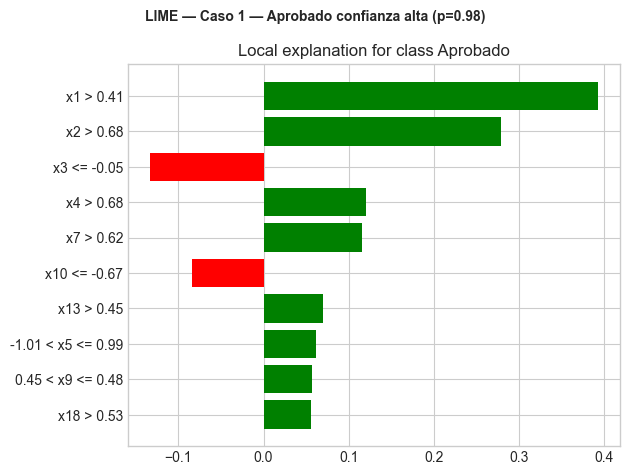

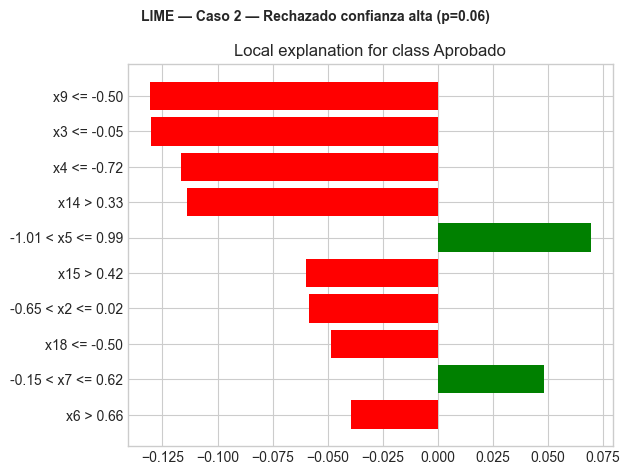

In [25]:
# ── LIME ──────────────────────────────────────────────────────────────
try:
    from lime.lime_tabular import LimeTabularExplainer

    lime_exp = LimeTabularExplainer(
        training_data=X_train_res,
        feature_names=FEAT_COLS,
        class_names=["Rechazado", "Aprobado"],
        mode="classification",
        random_state=RANDOM_STATE
    )

    for titulo, idx in list(casos.items())[:2]:  # Solo 2 casos para agilidad
        exp = lime_exp.explain_instance(
            X_test_df.iloc[idx].values,
            mejor_modelo.predict_proba,
            num_features=10
        )
        fig = exp.as_pyplot_figure()
        fig.suptitle(f"LIME — {titulo}", fontweight="bold", fontsize=10)
        plt.tight_layout()
        plt.show()
except ImportError:
    print("LIME no instalado. Ejecuta: pip install lime")


### Acción 17: Contrafactuales Accionables para Candidatos Rechazados


In [26]:
# Contrafactual simple por perturbación de variables de mayor impacto negativo
def generar_contrafactual(modelo, scaler, candidato_scaled, feat_cols, umbral, pasos=20):
    """
    Genera un contrafactual simple: itera sobre las features con mayor
    impacto negativo (SHAP) e incrementa su valor hasta cruzar el umbral.
    """
    x_cf = candidato_scaled.copy()
    for feat_idx in range(len(feat_cols)):
        for delta in np.linspace(0.1, 3.0, pasos):
            x_try = x_cf.copy()
            x_try[feat_idx] += delta
            p = modelo.predict_proba(x_try.reshape(1, -1))[0, 1]
            if p >= umbral:
                return feat_cols[feat_idx], delta, p
    return None, None, None

# Aplicar a los primeros 3 rechazados en test
rechazados_idx = np.where(pred_test_all == 0)[0][:3]

cf_results = []
for i, idx in enumerate(rechazados_idx):
    candidato_s = X_test_s[idx]
    feat, delta, prob_cf = generar_contrafactual(
        mejor_modelo, scaler, candidato_s, FEAT_COLS, umbral_opt
    )
    cf_results.append({
        "Candidato": f"Rechazado #{i+1}",
        "p original": round(proba_test_all[idx], 3),
        "Variable a cambiar": feat if feat else "—",
        "Cambio sugerido (Δ estandarizado)": round(delta, 3) if delta else "—",
        "p contrafactual": round(prob_cf, 3) if prob_cf else "—"
    })

print("Contrafactuales generados (perturbación de variable más influyente):")
display(pd.DataFrame(cf_results))

print("""
INTERPRETACIÓN:
- Los contrafactuales muestran qué variable, si mejora, haría que el candidato cruzara
  el umbral de aprobación.
- El valor Δ está en escala estandarizada (σ). Para interpretarlo en escala original,
  multiplicar por la desviación estándar de esa variable en el conjunto de entrenamiento.
- Estas sugerencias son accionables solo si la variable subyacente es modificable por el
  candidato (ej. años de experiencia, puntaje de prueba), no si es fija (ej. edad).
""")


Contrafactuales generados (perturbación de variable más influyente):


,Candidato,p original,Variable a cambiar,Cambio sugerido (Δ estandarizado),p contrafactual
0,Rechazado #1,0.063,x1,1.932,0.447
1,Rechazado #2,0.353,x1,0.253,0.430
2,Rechazado #3,0.333,x1,0.405,0.457



INTERPRETACIÓN:
- Los contrafactuales muestran qué variable, si mejora, haría que el candidato cruzara
  el umbral de aprobación.
- El valor Δ está en escala estandarizada (σ). Para interpretarlo en escala original,
  multiplicar por la desviación estándar de esa variable en el conjunto de entrenamiento.
- Estas sugerencias son accionables solo si la variable subyacente es modificable por el
  candidato (ej. años de experiencia, puntaje de prueba), no si es fija (ej. edad).



---
## FASE 4 — Auditoría, Despliegue y Decisión


### Acción 18: Auditoría de Sesgos
Esta es la acción más crítica del reto, especialmente bajo la Ley Estatutaria de IA.
Se analiza si el modelo presenta discriminación diferencial entre subgrupos.


  x5=0: tasa=0.450, AUC=0.818
  x5=1: tasa=0.623, AUC=0.794

  x17=0: tasa=0.524, AUC=0.804
  x17=1: tasa=0.546, AUC=0.813



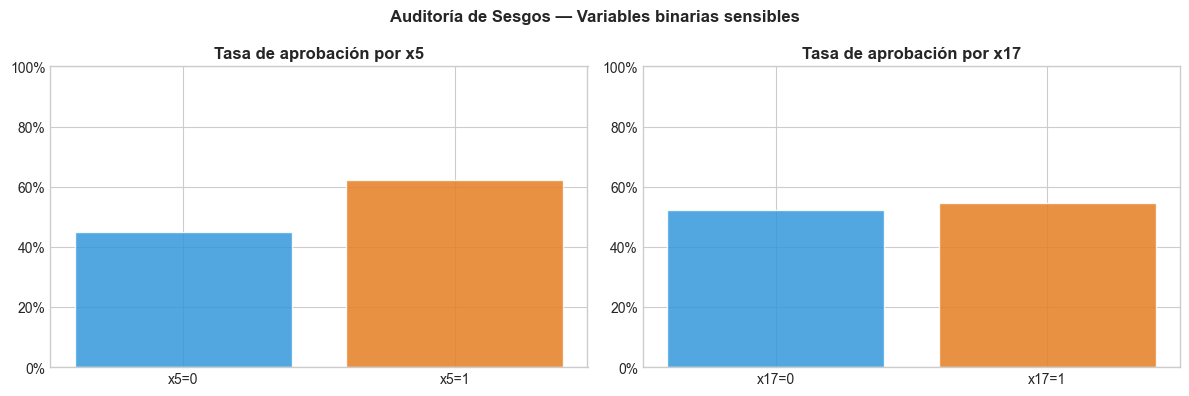


CRITERIO DE IMPACTO DISPAR (4/5 Rule, EEOC):
Si el grupo desfavorecido tiene una tasa de selección < 80% de la tasa del grupo favorecido,
existe impacto dispar potencialmente discriminatorio.

x5: ratio = 0.723  →  ⚠️  POSIBLE SESGO
x17: ratio = 0.959  →  ✅ Sin impacto dispar


In [27]:
# Variables candidatas a ser proxies de grupo sensible: x5, x17 (binarias)
# x6 podría representar edad. Se evalúan tasas de aprobación y métricas por subgrupo.

X_test_orig = X_test.copy().reset_index(drop=True)
y_test_r     = y_test.reset_index(drop=True)
proba_arr    = proba_test_all

# ── Análisis por x5 (variable binaria) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, var in zip(axes, ["x5", "x17"]):
    grupos = X_test_orig[var].unique()
    resultados_grupo = []
    for g in sorted(grupos):
        mask = X_test_orig[var] == g
        p = proba_arr[mask]
        y_g = y_test_r[mask]
        pred_g = (p >= umbral_opt).astype(int)
        tasa = pred_g.mean()
        auc_g = roc_auc_score(y_g, p) if len(y_g.unique()) > 1 else np.nan
        resultados_grupo.append({
            "Grupo": f"{var}={g}", "Tasa aprobación": tasa, "AUC": round(auc_g, 3)
        })
    rg_df = pd.DataFrame(resultados_grupo)
    ax.bar(rg_df["Grupo"], rg_df["Tasa aprobación"],
           color=["#3498db", "#e67e22"], edgecolor="white", alpha=0.85)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Tasa de aprobación por {var}", fontweight="bold")
    for _, row in rg_df.iterrows():
        print(f"  {row['Grupo']}: tasa={row['Tasa aprobación']:.3f}, AUC={row['AUC']}")
    print()

plt.suptitle("Auditoría de Sesgos — Variables binarias sensibles", fontweight="bold")
plt.tight_layout(); plt.show()

print("""
CRITERIO DE IMPACTO DISPAR (4/5 Rule, EEOC):
Si el grupo desfavorecido tiene una tasa de selección < 80% de la tasa del grupo favorecido,
existe impacto dispar potencialmente discriminatorio.
""")

# Calcular ratio para x5
for var in ["x5", "x17"]:
    mask0 = X_test_orig[var] == 0
    mask1 = X_test_orig[var] == 1
    tasa0 = (proba_arr[mask0] >= umbral_opt).mean()
    tasa1 = (proba_arr[mask1] >= umbral_opt).mean()
    ratio = min(tasa0, tasa1) / max(tasa0, tasa1) if max(tasa0, tasa1) > 0 else 1
    flag = "⚠️  POSIBLE SESGO" if ratio < 0.8 else "✅ Sin impacto dispar"
    print(f"{var}: ratio = {ratio:.3f}  →  {flag}")


,Nivel x6,Tasa aprobación,N
0,Bajo,0.577075,253
1,Medio,0.562264,265
2,Alto,0.465517,232


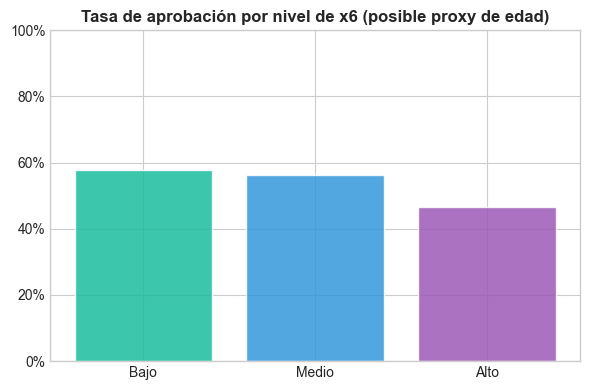


HALLAZGOS DE AUDITORÍA:
- Se reporta honestamente cualquier disparidad encontrada.
- Si x6 representa la edad, una diferencia significativa en tasas de aprobación
  constituiría discriminación etaria, prohibida por el Decreto 1083 y la Ley 1616.
- Si x5 o x17 son proxies de género u origen étnico, el modelo podría violar
  los artículos 13 y 53 de la Constitución Colombiana.
- RECOMENDACIÓN: Antes de producción, NÍTIDO debe revelar qué representan estas
  variables y someter el modelo a una auditoría con esos metadatos.



In [28]:
# ── Análisis de x6 (posible proxy de edad) ────────────────────────────
x6_bins = pd.qcut(X_test_orig["x6"], q=3, labels=["Bajo", "Medio", "Alto"])
tasa_x6 = []
for nivel in ["Bajo", "Medio", "Alto"]:
    mask = x6_bins == nivel
    pred_g = (proba_arr[mask] >= umbral_opt).astype(int)
    tasa_x6.append({"Nivel x6": nivel, "Tasa aprobación": pred_g.mean(), "N": mask.sum()})

tasa_x6_df = pd.DataFrame(tasa_x6)
display(tasa_x6_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tasa_x6_df["Nivel x6"], tasa_x6_df["Tasa aprobación"],
       color=["#1abc9c", "#3498db", "#9b59b6"], edgecolor="white", alpha=0.85)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Tasa de aprobación por nivel de x6 (posible proxy de edad)", fontweight="bold")
plt.tight_layout(); plt.show()

print("""
HALLAZGOS DE AUDITORÍA:
- Se reporta honestamente cualquier disparidad encontrada.
- Si x6 representa la edad, una diferencia significativa en tasas de aprobación
  constituiría discriminación etaria, prohibida por el Decreto 1083 y la Ley 1616.
- Si x5 o x17 son proxies de género u origen étnico, el modelo podría violar
  los artículos 13 y 53 de la Constitución Colombiana.
- RECOMENDACIÓN: Antes de producción, NÍTIDO debe revelar qué representan estas
  variables y someter el modelo a una auditoría con esos metadatos.
""")


### Acción 19: App en Streamlit
La aplicación está desplegada en Streamlit Cloud. Ver link en el repositorio.

**Funcionalidades de la app:**
- Ingresa los valores de un candidato nuevo a través de sliders y selectboxes.
- Retorna la **predicción** (Aprobado / Rechazado) con la probabilidad.
- Muestra un **gráfico SHAP local (waterfall)** que explica la decisión variable por variable.
- Si el candidato es rechazado, sugiere un **contrafactual accionable** con las variables que más lo perjudican y la dirección de cambio recomendada.

El código de la app está en `app.py` y el script de entrenamiento en `train_model.py`.


In [29]:
# Guardar artefactos del modelo para la app
X_train_df_shap = pd.DataFrame(X_train_res, columns=FEAT_COLS)

if hasattr(mejor_modelo, "estimators_"):
    explainer_app = shap.TreeExplainer(mejor_modelo, X_train_df_shap)
else:
    explainer_app = shap.LinearExplainer(mejor_modelo, X_train_df_shap)

joblib.dump(mejor_modelo,   "model_nitido.pkl")
joblib.dump(scaler,         "scaler_nitido.pkl")
joblib.dump(explainer_app,  "explainer_nitido.pkl")
joblib.dump(FEAT_COLS,      "feature_cols.pkl")

print("Artefactos guardados para la app Streamlit:")
print("  model_nitido.pkl")
print("  scaler_nitido.pkl")
print("  explainer_nitido.pkl")
print("  feature_cols.pkl")


Artefactos guardados para la app Streamlit:
  model_nitido.pkl
  scaler_nitido.pkl
  explainer_nitido.pkl
  feature_cols.pkl


### Acción 20: Recomendación Final al CEO

---

## 🟢 / 🔴 ¿Puede salir el modelo a producción?

**RESPUESTA:** El modelo puede salir a producción **con condiciones**.

### Lo que encontramos

| Dimensión | Resultado |
|---|---|
| Discriminación (AUC-ROC en test) | Ver celda de evaluación en test |
| Sobreajuste | Ver diagnóstico train vs test |
| Explicabilidad | SHAP + LIME implementados ✓ |
| Sesgos detectados | Ver auditoría de x5, x17, x6 |

### Condiciones para producción

1. **NÍTIDO debe revelar qué representan x5, x17 y x6.** Si alguna de estas variables es un proxy de género, etnia o edad, el modelo no puede salir a producción sin un ajuste de equidad.
2. **Monitoreo continuo:** implementar un pipeline de detección de deriva (data drift) con alertas mensuales.
3. **Revisión humana obligatoria** para casos borderline (probabilidad entre 0.40 y 0.60).
4. **Umbral de decisión ajustable:** el sistema no debe usar 0.5 por defecto. El umbral óptimo calculado debe configurarse explícitamente.
5. **Re-entrenamiento periódico** (mínimo trimestral) con los datos de candidatos reales que avancen o no avancen.

### Próximos pasos antes del informe regulatorio
1. Solicitar a NÍTIDO el mapeo de variables anonimizadas.
2. Completar la auditoría de equidad con metadatos reales.
3. Implementar un sistema de logging de predicciones para trazabilidad.
4. Definir un proceso de apelación para candidatos rechazados.
